# Rutinas de estimación, validación y pronóstico en series de tiempo financieras

En este notebook estudiaremos una familia de modelos clásicos para series de tiempo financieras:

- AR
- MA
- ARMA
- ARIMA
- SARIMA
- ARCH
- GARCH
- EGARCH
- GJR-GARCH

El objetivo no es únicamente correr modelos, sino entender:

1. Qué tipo de comportamiento financiero modela cada modelo.
2. Qué supuestos necesita.
3. Cómo se estima.
4. Cómo se valida.
5. Cómo se usa para pronosticar.
6. Qué limitaciones tiene.

En finanzas, normalmente trabajamos con precios, rendimientos y volatilidad.  
Los precios suelen ser no estacionarios, mientras que los rendimientos suelen ser más cercanos a la estacionariedad.

Por eso, antes de modelar, debemos distinguir entre:

- modelar el nivel del precio,
- modelar el rendimiento,
- modelar la volatilidad del rendimiento.

## Librerias 

In [8]:
#!pip install arch 

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import time 

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from arch import arch_model

import warnings
warnings.filterwarnings("ignore")

## Series de tiempo financieras

Una serie de tiempo es una sucesión de observaciones ordenadas en el tiempo.

En finanzas, las series más comunes son:

- precios de acciones,
- índices bursátiles,
- tasas de interés,
- tipos de cambio,
- rendimientos,
- volatilidades,
- spreads,
- inflación,
- primas de riesgo.

Una serie financiera se puede representar como:

$$
\{X_t\}_{t=1}^{T}
$$

donde $X_t$ es el valor observado en el tiempo $t$.

Si $P_t$ representa el precio de un activo, entonces podemos definir el rendimiento simple como:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

y el rendimiento logarítmico como:

$$
r_t = \log(P_t) - \log(P_{t-1})
$$

En modelos financieros, los rendimientos logarítmicos son muy usados porque:

1. son aproximadamente iguales a los rendimientos simples cuando los cambios son pequeños,
2. son aditivos en el tiempo,
3. suelen tener mejores propiedades estadísticas que los precios.

### Descarga y tratamiento de datos Financieros 

In [10]:
tickers = [
"AC.MX","AGUILASCPO.MX","ALTERNA.MX","ASURB.MX","BBVA.MX","CADUA.MX","CMOCTEZ.MX","DIABLOSO.MX","FINDEP.MX","GBMO.MX","GFINBURO.MX","GISSAA.MX","GOMO.MX","HERDEZ.MX","ICA.MX","LAMOSA.MX","MEGACPO.MX","ORBIA.MX","POSADASA.MX","QBINDUSA.MX","SAREB.MX","SPORTS.MX","TRAXIONA.MX","VESTA.MX",

"ACCELSAB.MX","AHMSA.MX","AMXB.MX","AUTLANB.MX","BEVIDESB.MX","CEMEXCPO.MX","CMRB.MX","CTAXTELA.MX","DINEB.MX","FRAGUAB.MX","GCARSOA1.MX","GFMULTIO.MX","GMD.MX","GPH1.MX","HIMEXSAA.MX","ICHB.MX","KOFUBL.MX","LASEG.MX","MFRISCOA-1.MX","PASAB.MX","PLANI.MX","QUMMAB.MX","SAVIAA.MX","TEAKCPO.MX","TS.MX","VINTE.MX",

"ACTINVRB.MX","ANB.MX","AXTELCPO.MX","BIMBOA.MX","CHDRAUIB.MX","COLLADO.MX","CUERVO.MX","FRES.MX","GCC.MX","GFNORTEO.MX","GMEXICOB.MX","GPROFUT.MX","HOMEX.MX","IDEALB-1.MX","KUOB.MX","LASITE.MX","MINSAB.MX","PE&OLES.MX","PROCORPB.MX","RCENTROA.MX","SIMECB.MX","TEKCHEMA.MX","UNIFINA.MX","VISTAA.MX",

"AGRIEXPA.MX","ALPEKA.MX","ARA.MX","BOLSAA.MX","CIEB.MX","CONVERA.MX","CULTIBAB.MX","ELEKTRA.MX","GAPB.MX","GENTERA.MX","GICSAB.MX","GRUMAB.MX","HOTEL.MX","INVEXA.MX","LABB.MX","LIVEPOL1.MX","NEMAKA.MX","PINFRA.MX","PV.MX","RA.MX","SITES1A-1.MX","TLEVISACPO.MX","VALUEGFO.MX","VITROA.MX",

"AGUA.MX","ALSEA.MX","ARISTOSA.MX","BBAJIOO.MX","CABLECPO.MX","CIDMEGA.MX","CREAL.MX","CYDSASAA.MX","FINAMEXO.MX","GAVA.MX","GIGANTE.MX","GNP.MX","HCITY.MX","IASASA.MX","KIMBERA.MX","LACOMERUBC.MX","MEDICAB.MX","OMAB.MX","POCHTECB.MX","Q.MX","RLHA.MX","SORIANAB.MX","TMMA.MX","VASCONI.MX","VOLARA.MX"
]

In [11]:
start = "2020-01-01"
end = None

datos_por_ticker = {}

for ticker in tickers:
    try:
        print(f"Descargando {ticker}...")
        # Descarga individual
        df = yf.download(ticker, start=start, auto_adjust=True, progress=False)
        
        if not df.empty:
            datos_por_ticker[ticker] = df
        else:
            print(f" Advertencia: {ticker} no devolvió datos.")
            
        # Pequeña pausa para no saturar la API de Yahoo
        time.sleep(0.5) 
        
    except Exception as e:
        print(f"Error de conexión con {ticker}: {e}")

Descargando AC.MX...
Descargando AGUILASCPO.MX...
Descargando ALTERNA.MX...
Descargando ASURB.MX...
Descargando BBVA.MX...
Descargando CADUA.MX...
Descargando CMOCTEZ.MX...
Descargando DIABLOSO.MX...
Descargando FINDEP.MX...
Descargando GBMO.MX...
Descargando GFINBURO.MX...
Descargando GISSAA.MX...
Descargando GOMO.MX...
Descargando HERDEZ.MX...
Descargando ICA.MX...
Descargando LAMOSA.MX...
Descargando MEGACPO.MX...
Descargando ORBIA.MX...
Descargando POSADASA.MX...
Descargando QBINDUSA.MX...
Descargando SAREB.MX...
Descargando SPORTS.MX...
Descargando TRAXIONA.MX...
Descargando VESTA.MX...
Descargando ACCELSAB.MX...
Descargando AHMSA.MX...
Descargando AMXB.MX...
Descargando AUTLANB.MX...
Descargando BEVIDESB.MX...
Descargando CEMEXCPO.MX...
Descargando CMRB.MX...
Descargando CTAXTELA.MX...
Descargando DINEB.MX...
Descargando FRAGUAB.MX...
Descargando GCARSOA1.MX...
Descargando GFMULTIO.MX...
Descargando GMD.MX...
Descargando GPH1.MX...
Descargando HIMEXSAA.MX...
Descargando ICHB.MX..

In [13]:
prices = pd.concat(
    {ticker: datos_por_ticker[ticker]["Close"] for ticker in tickers},
    axis=1
)
prices.head()

,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Ticker,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,77.489914,NaN,5.04542,273.006500,103.394829,6.920,38.725815,NaN,4.628801,9.022057,...,21.595089,9.244708,102.928604,5.95,62.165810,15.912635,23.509596,7.29,24.954985,20.020000
2020-01-03,78.181717,NaN,5.04780,274.346954,103.512558,7.100,38.725815,NaN,4.737714,9.022057,...,21.548567,9.249011,102.443832,5.95,62.025562,15.912635,23.755573,7.29,24.954985,20.190001
2020-01-06,77.889046,NaN,5.05114,269.337158,102.776680,7.115,38.725815,NaN,4.737714,9.022057,...,21.413654,8.894107,101.438141,5.90,62.859318,15.912635,23.391340,6.67,24.954985,19.795000
2020-01-07,78.622658,NaN,5.05159,272.309723,102.531403,7.100,38.725815,NaN,4.574345,9.022057,...,21.362482,8.894107,100.519257,5.95,63.256710,15.912635,23.651506,6.21,24.954985,20.059999
2020-01-08,78.364197,NaN,5.05225,275.051300,102.531403,7.110,38.326576,NaN,4.574345,9.022057,...,21.650913,9.249011,102.016953,5.95,62.048939,15.912635,23.462292,5.97,24.954985,20.250000


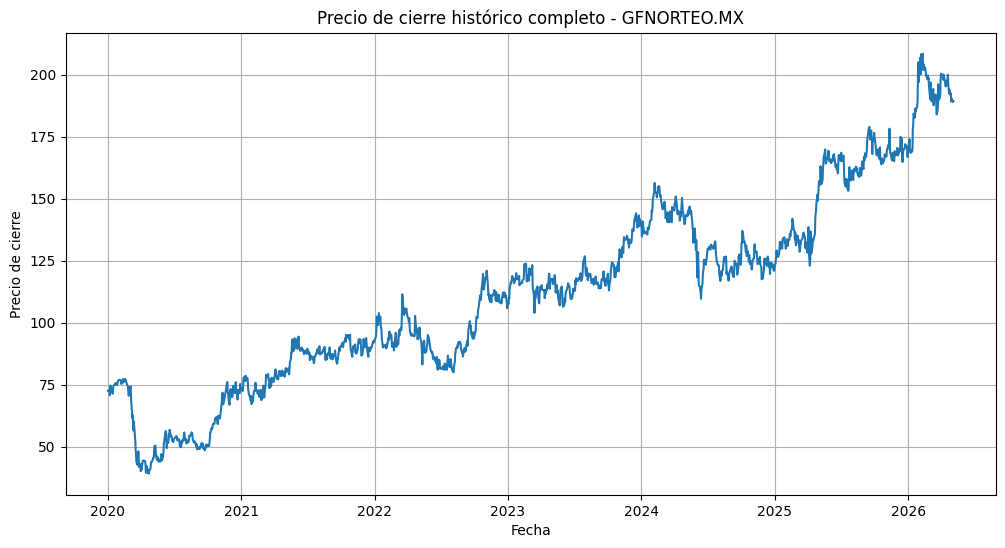

In [14]:
ticker = "GFNORTEO.MX"   
precio_completo = datos_por_ticker[ticker]["Close"].copy()
precio_completo = precio_completo.sort_index().dropna()

plt.figure(figsize=(12, 6))
plt.plot(precio_completo.index, precio_completo.values)

plt.title(f"Precio de cierre histórico completo - {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.grid(True)

plt.show()

In [16]:
missing_count = prices.isna().sum().sort_values(ascending=False)
missing_count

DIABLOSO.MX      1361
AGUILASCPO.MX    1123
CTAXTELA.MX       857
LASITE.MX         701
SITES1A-1.MX      556
                 ... 
OMAB.MX             1
VASCONI.MX          1
SORIANAB.MX         1
VOLARA.MX           1
LACOMERUBC.MX       0
Length: 123, dtype: int64

In [17]:
missing_pct = (prices.isna().mean() * 100).sort_values(ascending=False)
missing_pct

DIABLOSO.MX      85.436284
AGUILASCPO.MX    70.495920
CTAXTELA.MX      53.797866
LASITE.MX        44.005022
SITES1A-1.MX     34.902699
                   ...    
OMAB.MX           0.062775
VASCONI.MX        0.062775
SORIANAB.MX       0.062775
VOLARA.MX         0.062775
LACOMERUBC.MX     0.000000
Length: 123, dtype: float64

In [18]:
missing_dates = prices[prices.isna().any(axis=1)]

missing_dates.head()

,AC.MX,AGUILASCPO.MX,ALTERNA.MX,ASURB.MX,BBVA.MX,CADUA.MX,CMOCTEZ.MX,DIABLOSO.MX,FINDEP.MX,GBMO.MX,...,LACOMERUBC.MX,MEDICAB.MX,OMAB.MX,POCHTECB.MX,Q.MX,RLHA.MX,SORIANAB.MX,TMMA.MX,VASCONI.MX,VOLARA.MX
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,77.489914,NaN,5.04542,273.006500,103.394829,6.920,38.725815,NaN,4.628801,9.022057,...,21.595089,9.244708,102.928604,5.95,62.165810,15.912635,23.509596,7.29,24.954985,20.020000
2020-01-03,78.181717,NaN,5.04780,274.346954,103.512558,7.100,38.725815,NaN,4.737714,9.022057,...,21.548567,9.249011,102.443832,5.95,62.025562,15.912635,23.755573,7.29,24.954985,20.190001
2020-01-06,77.889046,NaN,5.05114,269.337158,102.776680,7.115,38.725815,NaN,4.737714,9.022057,...,21.413654,8.894107,101.438141,5.90,62.859318,15.912635,23.391340,6.67,24.954985,19.795000
2020-01-07,78.622658,NaN,5.05159,272.309723,102.531403,7.100,38.725815,NaN,4.574345,9.022057,...,21.362482,8.894107,100.519257,5.95,63.256710,15.912635,23.651506,6.21,24.954985,20.059999
2020-01-08,78.364197,NaN,5.05225,275.051300,102.531403,7.110,38.326576,NaN,4.574345,9.022057,...,21.650913,9.249011,102.016953,5.95,62.048939,15.912635,23.462292,5.97,24.954985,20.250000


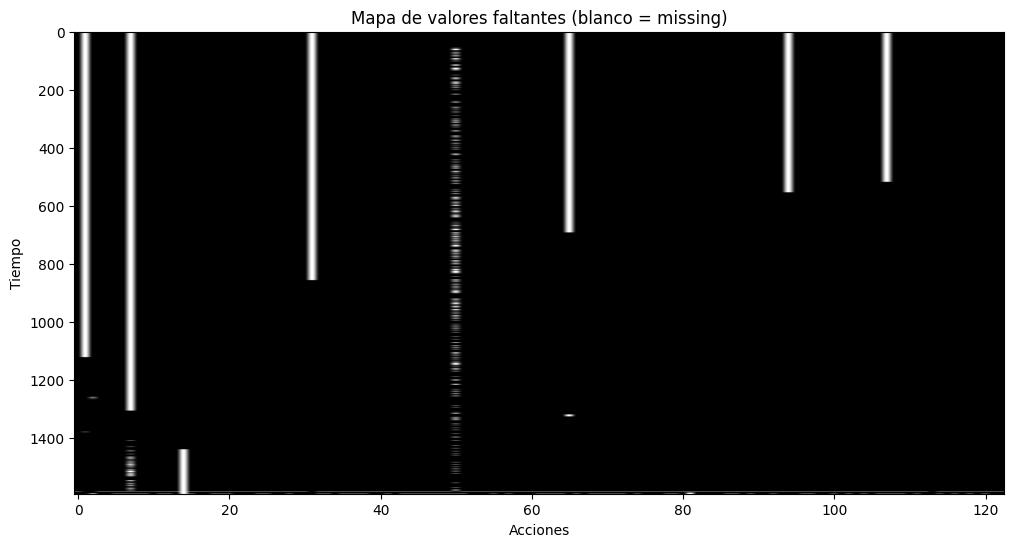

In [19]:
plt.figure(figsize=(12,6))
plt.imshow(prices.isna(), aspect='auto', cmap='gray')
plt.xlabel("Acciones")
plt.ylabel("Tiempo")
plt.title("Mapa de valores faltantes (blanco = missing)")
plt.show()

Tomamos un Rango: 

In [24]:
periodo_inicio = "2025-03-11"
periodo_fin = "2026-04-5"

prices_common_window = prices.loc[periodo_inicio:periodo_fin].copy()

In [25]:
print("Filas totales en el rango:", len(prices_common_window))
print("Filas completas en el rango:", len(prices_common_window.dropna()))

Filas totales en el rango: 266
Filas completas en el rango: 104


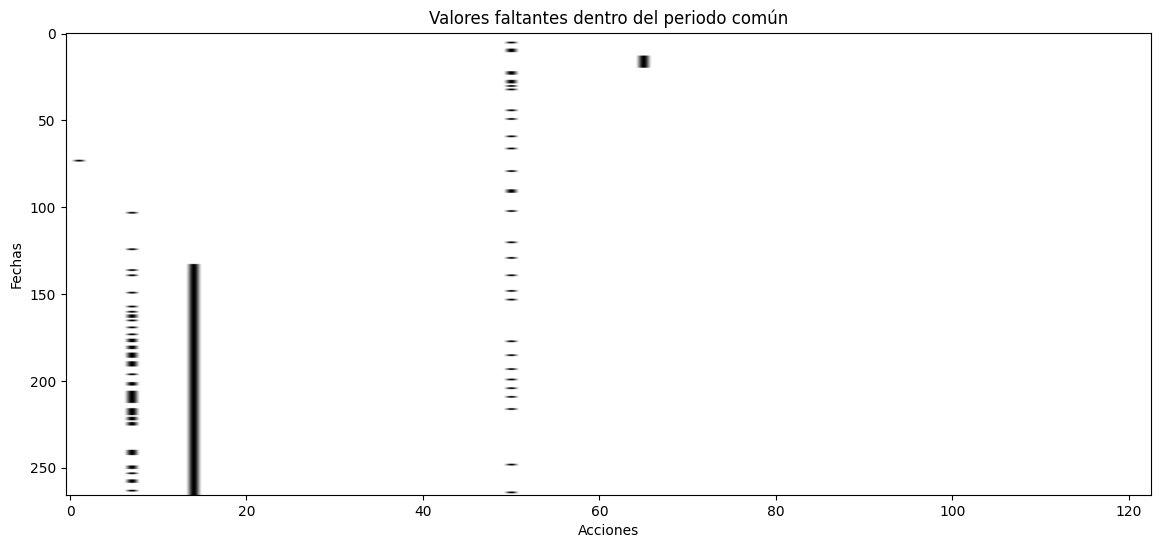

In [26]:
plt.figure(figsize=(14,6))
plt.imshow(prices_common_window.isna(), aspect='auto', cmap='gray_r')
plt.xlabel("Acciones")
plt.ylabel("Fechas")
plt.title("Valores faltantes dentro del periodo común")
plt.show()

In [29]:
df_work = prices_common_window.copy()
missing_pct = df_work.isna().mean()

# Columnas a eliminar
cols_drop = missing_pct[missing_pct > 0.15].index.tolist()

print("Columnas eliminadas (>15% faltantes):")
print(cols_drop)

df_work = df_work.drop(columns=cols_drop)


Columnas eliminadas (>15% faltantes):
['DIABLOSO.MX', 'ICA.MX']


In [30]:
def find_nan_runs(series):
    """
    Regresa una lista de tuplas (start_idx, end_idx, run_length)
    para cada bloque consecutivo de NaN en una serie.
    """
    is_nan = series.isna().values
    runs = []
    n = len(series)
    i = 0
    
    while i < n:
        if is_nan[i]:
            start = i
            while i < n and is_nan[i]:
                i += 1
            end = i - 1
            runs.append((start, end, end - start + 1))
        else:
            i += 1
    
    return runs

#### Caso 1

Rachas cortas (≤ 3 valores consecutivos) Se imputan usando el promedio de los últimos 5 valores observados anteriores.

In [31]:
def fill_short(series, start, end, window=5):
    s = series.copy()

    for idx in range(start, end + 1):
        prev = s.iloc[max(0, idx-window):idx].dropna()
        if len(prev) > 0:
            s.iloc[idx] = prev.mean()

    return s

#### Caso 2

Rachas largas (> 3 valores consecutivos)
Se utiliza interpolación lineal entre el último valor observado antes del bloque y el primer valor observado después del bloque.

Esto permite:
- Mantener continuidad temporal
- Evitar valores constantes artificiales
- Preservar tendencias

En caso de no existir un valor anterior o posterior, los valores se dejan como NaN.

In [32]:
def fill_long_linear(series, start, end):
    s = series.copy()

    prev_idx = start - 1
    next_idx = end + 1

    if prev_idx >= 0 and next_idx < len(s):
        prev_val = s.iloc[prev_idx]
        next_val = s.iloc[next_idx]

        if pd.notna(prev_val) and pd.notna(next_val):
            run_len = end - start + 1

            for k, idx in enumerate(range(start, end + 1), start=1):
                s.iloc[idx] = prev_val + (next_val - prev_val) * (k / (run_len + 1))

    return s

#### Aplicamos las estrategias 

In [33]:
def impute_series(series):
    s = series.copy()
    runs = find_nan_runs(s)

    for start, end, length in runs:
        if length <= 3:
            s = fill_short(s, start, end)
        else:
            s = fill_long_linear(s, start, end)

    return s

In [34]:
df_imputed = df_work.copy()

for col in df_imputed.columns:
    df_imputed[col] = impute_series(df_imputed[col])

In [35]:
print("NaN antes:", df_work.isna().sum().sum())
print("NaN después:", df_imputed.isna().sum().sum())

NaN antes: 39
NaN después: 0


In [36]:
mask_original = df_work.isna()
mask_imputed = mask_original & df_imputed.notna()

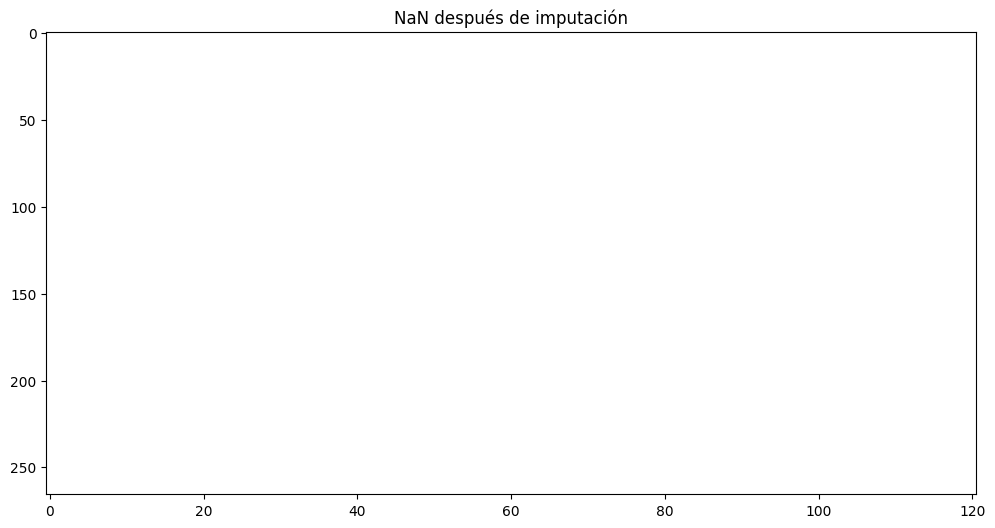

In [37]:
plt.figure(figsize=(12,6))
plt.imshow(df_imputed.isna(), aspect='auto', cmap='gray_r')
plt.title("NaN después de imputación")
plt.show()

### Series 

In [41]:
# Tomamos solo un ticker para el analisis de la serie de tiempo 
ticker = "GFNORTEO.MX"
df_sr = df_imputed[[ticker]].copy()
df_sr = df_sr.rename(columns={ticker: "Close"})

In [43]:
df_sr["log_price"] = np.log(df_sr["Close"])
df_sr["return"] = df_sr["log_price"].diff()

## Estacionariedad

Antes de estimar modelos AR, MA, ARMA o ARIMA, necesitamos hablar de estacionariedad.

Una serie es estacionaria si sus propiedades estadísticas no cambian en el tiempo.

En términos prácticos, una serie estacionaria tiene:

1. media constante,
2. varianza constante,
3. autocovarianza que depende solo del rezago, no del momento del tiempo.

Formalmente, una serie $X_t$ es débilmente estacionaria si:

$$
E[X_t] = \mu
$$

$$
Var(X_t) = \sigma^2
$$

$$
Cov(X_t, X_{t-k}) = \gamma_k
$$

Esto es importante porque muchos modelos clásicos asumen estacionariedad.

En finanzas:

- los precios normalmente no son estacionarios,
- los rendimientos suelen ser más estacionarios,
- la volatilidad puede cambiar en el tiempo.

Por eso, para ARMA normalmente usamos rendimientos, no precios.

In [44]:
def adf_test(series):
    result = adfuller(series.dropna())
    
    print("Estadístico ADF:", result[0])
    print("p-value:", result[1])
    print("Rezagos usados:", result[2])
    print("Número de observaciones:", result[3])
    
    if result[1] < 0.05:
        print("Conclusión: se rechaza raíz unitaria. La serie parece estacionaria.")
    else:
        print("Conclusión: no se rechaza raíz unitaria. La serie podría no ser estacionaria.")

## Autocorrelación y dependencia temporal

Una idea central en series de tiempo es que el presente puede depender del pasado.

La autocorrelación mide qué tanto se relaciona la serie consigo misma en distintos rezagos.

La autocorrelación de orden $k$ mide la relación entre:

$$
X_t
$$

y

$$
X_{t-k}
$$

La función de autocorrelación se conoce como ACF.

También usamos la función de autocorrelación parcial, PACF, que mide la relación directa entre $X_t$ y $X_{t-k}$ quitando el efecto de los rezagos intermedios.

Estas gráficas ayudan a identificar modelos:

- AR: suele observarse en la PACF.
- MA: suele observarse en la ACF.
- ARMA: suele tener patrones más mezclados.

In [45]:
def plot_acf_pacf(series, lags=40):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    plot_acf(series.dropna(), lags=lags, ax=axes[0])
    axes[0].set_title("ACF")
    
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], method="ywm")
    axes[1].set_title("PACF")
    
    plt.show()

## Modelo AR(p)

Un modelo autorregresivo AR(p) supone que el valor actual depende linealmente de sus propios valores pasados.

El modelo AR(p) se escribe como:

$$
X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \varepsilon_t
$$

donde:

- $X_t$ es la serie en el tiempo $t$,
- $c$ es una constante,
- $\phi_1, \ldots, \phi_p$ son parámetros autorregresivos,
- $p$ es el número de rezagos,
- $\varepsilon_t$ es un error aleatorio o innovación.

La intuición financiera es la siguiente:

si usamos rendimientos, un AR(p) pregunta si los rendimientos pasados tienen poder predictivo sobre el rendimiento actual.

Por ejemplo, un AR(1):

$$
r_t = c + \phi_1 r_{t-1} + \varepsilon_t
$$

Si $\phi_1 > 0$, un rendimiento positivo ayer tiende a estar asociado con un rendimiento positivo hoy.

Si $\phi_1 < 0$, podría existir reversión a la media.

Si $\phi_1 \approx 0$, el rendimiento pasado no ayuda mucho a explicar el rendimiento actual.

In [46]:
# AR(p) usando ARIMA con q = 0 y d = 0

p = 1
modelo_ar = ARIMA(df_sr["return"], order=(p, 0, 0))
resultado_ar = modelo_ar.fit()
print(resultado_ar.summary())

                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                  266
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 675.686
Date:                Tue, 05 May 2026   AIC                          -1345.373
Time:                        09:53:32   BIC                          -1334.622
Sample:                             0   HQIC                         -1341.054
                                - 266                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.001      1.483      0.138      -0.001       0.004
ar.L1         -0.0614      0.043     -1.435      0.151      -0.145       0.022
sigma2         0.0004   2.19e-05     16.335      0.0

## Modelo MA(q)

Un modelo de medias móviles MA(q) supone que el valor actual depende de errores pasados.

El modelo MA(q) se escribe como:

$$
X_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q}
$$

donde:

- $\mu$ es la media de la serie,
- $\varepsilon_t$ es el shock actual,
- $\varepsilon_{t-1}, \ldots, \varepsilon_{t-q}$ son shocks pasados,
- $\theta_1, \ldots, \theta_q$ son parámetros del modelo.

La intuición financiera es que el rendimiento actual puede estar influido por sorpresas recientes del mercado.

Un modelo MA no dice necesariamente que el rendimiento dependa directamente del rendimiento pasado, sino de los errores o shocks que ocurrieron en el pasado.

Por ejemplo, un MA(1):

$$
r_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1}
$$

Si $\theta_1$ es significativo, significa que el shock anterior todavía tiene impacto en el rendimiento actual.

In [47]:
q = 1
modelo_ma = ARIMA(df_sr["return"], order=(0, 0, q))
resultado_ma = modelo_ma.fit()
print(resultado_ma.summary())

                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                  266
Model:                 ARIMA(0, 0, 1)   Log Likelihood                 676.210
Date:                Tue, 05 May 2026   AIC                          -1346.421
Time:                        09:55:39   BIC                          -1335.670
Sample:                             0   HQIC                         -1342.102
                                - 266                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      1.586      0.113      -0.000       0.004
ma.L1         -0.1253      0.046     -2.707      0.007      -0.216      -0.035
sigma2         0.0004   2.19e-05     16.213      0.0

## Modelo ARMA(p,q)

El modelo ARMA combina una parte autorregresiva y una parte de medias móviles.

El modelo ARMA(p,q) se escribe como:

$$
X_t =
c
+ \phi_1 X_{t-1}
+ \cdots
+ \phi_p X_{t-p}
+ \varepsilon_t
+ \theta_1 \varepsilon_{t-1}
+ \cdots
+ \theta_q \varepsilon_{t-q}
$$

La parte AR captura dependencia directa con valores pasados.

La parte MA captura dependencia con shocks pasados.

En finanzas, ARMA se usa principalmente para modelar la media condicional de los rendimientos.

La media condicional es:

$$
E[r_t|\mathcal{F}_{t-1}]
$$

es decir, el rendimiento esperado hoy dado lo que sabíamos hasta ayer.

Sin embargo, en muchos activos financieros, la media de los rendimientos es difícil de predecir. Por eso, los modelos ARMA suelen tener mayor utilidad como parte de un modelo más grande, por ejemplo:

$$
r_t = \mu_t + \varepsilon_t
$$

donde $\mu_t$ puede ser ARMA y la varianza de $\varepsilon_t$ puede modelarse con GARCH.

In [48]:
p = 1
q = 1
modelo_arma = ARIMA(df_sr["return"], order=(p, 0, q))
resultado_arma = modelo_arma.fit()
print(resultado_arma.summary())

                               SARIMAX Results                                
Dep. Variable:                 return   No. Observations:                  266
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 678.872
Date:                Tue, 05 May 2026   AIC                          -1349.743
Time:                        09:56:42   BIC                          -1335.409
Sample:                             0   HQIC                         -1343.985
                                - 266                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0016      0.001      1.832      0.067      -0.000       0.003
ar.L1          0.4074      0.201      2.027      0.043       0.014       0.801
ma.L1         -0.5615      0.187     -3.009      0.0

## Modelo ARIMA(p,d,q)

ARIMA significa:

- AR: autorregresivo,
- I: integrado,
- MA: medias móviles.

El modelo ARIMA se usa cuando la serie original no es estacionaria, pero puede volverse estacionaria después de diferenciarla.

El parámetro $d$ indica cuántas diferencias se aplican.

La primera diferencia es:

$$
\Delta X_t = X_t - X_{t-1}
$$

Si la serie necesita una diferencia, usamos $d=1$.

Un modelo ARIMA(p,d,q) aplica un ARMA(p,q) sobre la serie diferenciada.

Por ejemplo, ARIMA(1,1,1) significa:

1. primero diferenciamos la serie una vez,
2. luego estimamos un ARMA(1,1) sobre la serie diferenciada.

En finanzas, ARIMA puede usarse para precios, aunque muchas veces se prefiere trabajar directamente con rendimientos.

In [49]:
p = 1
d = 1
q = 1

modelo_arima = ARIMA(df_sr["Close"], order=(p, d, q))
resultado_arima = modelo_arima.fit()
print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  266
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -675.653
Date:                Tue, 05 May 2026   AIC                           1357.307
Time:                        09:57:30   BIC                           1368.046
Sample:                             0   HQIC                          1361.621
                                - 266                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3870      0.236      1.643      0.100      -0.075       0.849
ma.L1         -0.5275      0.215     -2.454      0.014      -0.949      -0.106
sigma2         9.5953      0.659     14.565      0.0

## Modelo SARIMA

SARIMA extiende ARIMA incorporando componentes estacionales.

Se escribe como:

$$
SARIMA(p,d,q)(P,D,Q)_s
$$

donde:

- $(p,d,q)$ describe la parte no estacional,
- $(P,D,Q)$ describe la parte estacional,
- $s$ es la periodicidad.

Por ejemplo, si trabajamos con datos mensuales y hay patrón anual, entonces:

$$
s = 12
$$

Si trabajamos con datos diarios financieros, la estacionalidad puede aparecer por:

- día de la semana,
- fin de mes,
- vencimientos de derivados,
- efectos calendario,
- anuncios macroeconómicos recurrentes.

SARIMA es más común en series macroeconómicas o de negocio que en rendimientos bursátiles diarios, pero puede ser útil cuando hay patrones estacionales claros.

In [50]:
modelo_sarima = SARIMAX(
    df_sr["Close"],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12)
)

resultado_sarima = modelo_sarima.fit()
print(resultado_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                  266
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -674.317
Date:                            Tue, 05 May 2026   AIC                           1358.633
Time:                                    09:59:04   BIC                           1376.532
Sample:                                         0   HQIC                          1365.824
                                            - 266                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3927      0.263      1.495      0.135      -0.122       0.907
ma.L1         -0.5238      0.245   

**Limitación de ARMA/ARIMA: volatilidad cambiante**

Los modelos AR, MA, ARMA y ARIMA se enfocan principalmente en modelar la media condicional.

Pero en finanzas hay un fenómeno muy importante:

la volatilidad no es constante.

Los rendimientos financieros suelen mostrar:

1. períodos tranquilos,
2. períodos turbulentos,
3. agrupamiento de volatilidad,
4. colas pesadas,
5. respuestas asimétricas ante noticias positivas y negativas.

El agrupamiento de volatilidad significa que días muy volátiles tienden a estar cerca de otros días volátiles.

Esto se observa en los rendimientos financieros: aunque los rendimientos no sean fácilmente predecibles, la volatilidad sí suele ser más persistente.

Por eso usamos modelos ARCH y GARCH.

## Modelo ARCH(q)

ARCH significa Autoregressive Conditional Heteroskedasticity.

La idea central es que la varianza condicional cambia en el tiempo.

Supongamos que:

$$
r_t = \mu + \varepsilon_t
$$

donde:

$$
\varepsilon_t = \sigma_t z_t
$$

y:

$$
z_t \sim N(0,1)
$$

En un modelo ARCH(q), la varianza condicional se modela como:

$$
\sigma_t^2 =
\omega
+ \alpha_1 \varepsilon_{t-1}^2
+ \alpha_2 \varepsilon_{t-2}^2
+ \cdots
+ \alpha_q \varepsilon_{t-q}^2
$$

La intuición financiera es:

si ayer hubo un shock grande, positivo o negativo, entonces hoy esperamos mayor volatilidad.

Por eso se usan errores al cuadrado.

Un shock de $-5\%$ y uno de $+5\%$ tienen el mismo impacto en la varianza porque ambos generan:

$$
\varepsilon_t^2
$$

El modelo ARCH captura agrupamiento de volatilidad, pero puede necesitar muchos rezagos para explicar bien la persistencia.

In [53]:
returns_arch = df_sr["return"].replace([np.inf, -np.inf], np.nan).dropna() * 100

modelo_arch = arch_model(
    returns_arch,
    mean="Constant",
    vol="ARCH",
    p=1,
    dist="normal"
)

resultado_arch = modelo_arch.fit()
print(resultado_arch.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 848.8883170831668
Iteration:      2,   Func. Count:     11,   Neg. LLF: 550.5874734155738
Iteration:      3,   Func. Count:     16,   Neg. LLF: 539.0974391522635
Iteration:      4,   Func. Count:     21,   Neg. LLF: 538.0311750483033
Iteration:      5,   Func. Count:     25,   Neg. LLF: 538.0311554116286
Iteration:      6,   Func. Count:     28,   Neg. LLF: 538.0311554116374
Optimization terminated successfully    (Exit mode 0)
            Current function value: 538.0311554116286
            Iterations: 6
            Function evaluations: 28
            Gradient evaluations: 6
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -538.031
Distribution:                  Normal   AIC: 

## Modelo GARCH(p,q)

GARCH extiende ARCH agregando rezagos de la propia varianza condicional.

El modelo GARCH(p,q) se escribe como:

$$
\sigma_t^2 =
\omega
+ \alpha_1 \varepsilon_{t-1}^2
+ \cdots
+ \alpha_q \varepsilon_{t-q}^2
+ \beta_1 \sigma_{t-1}^2
+ \cdots
+ \beta_p \sigma_{t-p}^2
$$

El caso más usado en finanzas es GARCH(1,1):

$$
\sigma_t^2 =
\omega
+ \alpha \varepsilon_{t-1}^2
+ \beta \sigma_{t-1}^2
$$

La interpretación es:

- $\omega$: nivel base de volatilidad,
- $\alpha$: reacción ante shocks recientes,
- $\beta$: persistencia de la volatilidad.

Si $\alpha + \beta$ está cerca de 1, la volatilidad es muy persistente.

Esto significa que un evento de alta volatilidad tarda en desaparecer.

En finanzas, GARCH(1,1) suele ser un benchmark fuerte para pronosticar volatilidad.

In [55]:
returns_arch = df_sr["return"].replace([np.inf, -np.inf], np.nan).dropna() * 100

modelo_garch = arch_model(
    returns_arch,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

resultado_garch = modelo_garch.fit()
print(resultado_garch.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 194968219.75780547
Iteration:      2,   Func. Count:     13,   Neg. LLF: 569.3690419771826
Iteration:      3,   Func. Count:     19,   Neg. LLF: 553.4226971934536
Iteration:      4,   Func. Count:     25,   Neg. LLF: 664.0012122423789
Iteration:      5,   Func. Count:     31,   Neg. LLF: 539.6897389280247
Iteration:      6,   Func. Count:     37,   Neg. LLF: 528.530650253897
Iteration:      7,   Func. Count:     43,   Neg. LLF: 528.509481312612
Iteration:      8,   Func. Count:     49,   Neg. LLF: 528.5080173554973
Iteration:      9,   Func. Count:     53,   Neg. LLF: 528.50801735539
Optimization terminated successfully    (Exit mode 0)
            Current function value: 528.5080173554973
            Iterations: 9
            Function evaluations: 53
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 return   R-squared:                   

## Modelo EGARCH

EGARCH significa Exponential GARCH.

Este modelo trabaja con el logaritmo de la varianza condicional:

$$
\log(\sigma_t^2)
$$

Una forma del modelo EGARCH(1,1) es:

$ \log(\sigma_t^2) = \omega + \beta \log(\sigma_{t-1}^2) + \alpha \left(\frac{|\varepsilon_{t-1}|}{\sigma_{t-1}} - E|z_t|\right) + \gamma \frac{\varepsilon_{t-1}}{\sigma_{t-1}} $

La ventaja de EGARCH es que permite capturar asimetría.

En mercados financieros, las malas noticias suelen aumentar más la volatilidad que las buenas noticias.

Este fenómeno se conoce como efecto apalancamiento o leverage effect.

Si $\gamma$ es negativo, significa que shocks negativos aumentan más la volatilidad futura que shocks positivos de la misma magnitud.

Otra ventaja de EGARCH es que al modelar el logaritmo de la varianza, no necesita imponer las mismas restricciones de positividad que un GARCH estándar.

In [56]:
returns_arch = df_sr["return"].replace([np.inf, -np.inf], np.nan).dropna() * 100

modelo_egarch = arch_model(
    returns_arch,
    mean="Constant",
    vol="EGARCH",
    p=1,
    q=1,
    dist="normal"
)

resultado_egarch = modelo_egarch.fit()
print(resultado_egarch.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 535989777.6720381
Iteration:      2,   Func. Count:     14,   Neg. LLF: 6638870136.471315
Iteration:      3,   Func. Count:     22,   Neg. LLF: 834.5126975625035
Iteration:      4,   Func. Count:     29,   Neg. LLF: 641.9158458525235
Iteration:      5,   Func. Count:     35,   Neg. LLF: 529.9150210517337
Iteration:      6,   Func. Count:     40,   Neg. LLF: 529.8763731591848
Iteration:      7,   Func. Count:     45,   Neg. LLF: 529.8720513786816
Iteration:      8,   Func. Count:     50,   Neg. LLF: 529.8694317708866
Iteration:      9,   Func. Count:     55,   Neg. LLF: 529.8688187938378
Iteration:     10,   Func. Count:     60,   Neg. LLF: 529.8687827669935
Iteration:     11,   Func. Count:     66,   Neg. LLF: 529.8687064432019
Iteration:     12,   Func. Count:     71,   Neg. LLF: 529.8686946479208
Iteration:     13,   Func. Count:     76,   Neg. LLF: 529.8686919114747
Iteration:     14,   Func. Count:     81,   Neg. LLF: 529.868741

## Modelo GJR-GARCH

El modelo GJR-GARCH también permite capturar asimetría en la volatilidad.

Una especificación GJR-GARCH(1,1) es:

$$
\sigma_t^2 =
\omega
+ \alpha \varepsilon_{t-1}^2
+ \gamma I_{\{\varepsilon_{t-1}<0\}} \varepsilon_{t-1}^2
+ \beta \sigma_{t-1}^2
$$

donde:

$$
I_{\{\varepsilon_{t-1}<0\}}
$$

es una variable indicadora que vale 1 cuando el shock anterior fue negativo.

La interpretación es:

- si el shock anterior fue positivo, afecta la volatilidad mediante $\alpha$,
- si el shock anterior fue negativo, afecta mediante $\alpha + \gamma$.

Si $\gamma > 0$, entonces los shocks negativos aumentan más la volatilidad que los positivos.

Esto es muy relevante en mercados accionarios, donde las caídas suelen generar mayor incertidumbre que las subidas.

In [57]:
returns_arch = df_sr["return"].replace([np.inf, -np.inf], np.nan).dropna() * 100

modelo_gjr = arch_model(
    returns_arch,
    mean="Constant",
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    dist="normal"
)

resultado_gjr = modelo_gjr.fit()
print(resultado_gjr.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 33651926.074863896
Iteration:      2,   Func. Count:     15,   Neg. LLF: 128204.23888408561
Iteration:      3,   Func. Count:     22,   Neg. LLF: 551.1496808149493
Iteration:      4,   Func. Count:     30,   Neg. LLF: 578.1685412460023
Iteration:      5,   Func. Count:     37,   Neg. LLF: 534.6949554544838
Iteration:      6,   Func. Count:     44,   Neg. LLF: 550.1093306728243
Iteration:      7,   Func. Count:     51,   Neg. LLF: 531.4997453802342
Iteration:      8,   Func. Count:     58,   Neg. LLF: 527.8170749896034
Iteration:      9,   Func. Count:     64,   Neg. LLF: 527.8039886455529
Iteration:     10,   Func. Count:     70,   Neg. LLF: 527.8033658784883
Iteration:     11,   Func. Count:     76,   Neg. LLF: 527.8033414781507
Iteration:     12,   Func. Count:     82,   Neg. LLF: 527.8033371401253
Iteration:     13,   Func. Count:     87,   Neg. LLF: 527.803337140116
Optimization terminated successfully    (Exit mode 0)
         

## Rutina general de modelación

Para trabajar con series financieras, seguiremos una rutina ordenada.

**Paso 1:** Preparar la serie

Primero definimos si queremos modelar:

- precios,
- rendimientos,
- volatilidad.

En general:

- ARIMA puede aplicarse a precios si hay diferenciación.
- ARMA suele aplicarse a rendimientos.
- GARCH suele aplicarse a rendimientos para modelar volatilidad.

**Paso 2:** Revisar estacionariedad

Aplicamos pruebas como ADF.

Si la serie no es estacionaria, podemos diferenciarla.

**Paso 3:** Revisar ACF y PACF

La ACF y PACF ayudan a proponer órdenes iniciales para AR, MA, ARMA o ARIMA.

**Paso 4:** Estimar varios modelos candidatos

No conviene quedarse con un solo modelo sin comparación.

Podemos probar diferentes combinaciones:

$$
ARIMA(p,d,q)
$$

o diferentes modelos de volatilidad:

$$
ARCH, GARCH, EGARCH, GJR-GARCH
$$

**Paso 5:** Comparar modelos

Podemos comparar usando:

- AIC,
- BIC,
- log-verosimilitud,
- errores fuera de muestra,
- comportamiento de residuos.

**Paso 6:** Validar residuos

Un buen modelo debería dejar residuos sin estructura.

Es decir, después de ajustar el modelo, los residuos no deberían tener autocorrelación fuerte.

Para modelos GARCH, también revisamos si los residuos estandarizados ya no muestran heterocedasticidad condicional.

**Paso 7:** Pronosticar

Finalmente generamos pronósticos de:

- media,
- precio,
- rendimiento,
- volatilidad.

In [58]:
def train_test_split_time_series(series, test_size=0.2):
    n = len(series)
    split = int(n * (1 - test_size))
    
    train = series.iloc[:split]
    test = series.iloc[split:]
    
    return train, test

### Comparación por AIC y BIC

El AIC y el BIC son criterios de información.

Sirven para comparar modelos estimados sobre la misma serie.

El AIC se define como:

$$
AIC = -2\log(L) + 2k
$$

El BIC se define como:

$$
BIC = -2\log(L) + k\log(n)
$$

donde:

- $L$ es la verosimilitud del modelo,
- $k$ es el número de parámetros,
- $n$ es el número de observaciones.

Ambos criterios penalizan modelos demasiado complejos.

La regla práctica es:

menor AIC o menor BIC indica mejor balance entre ajuste y complejidad.

El BIC penaliza más fuerte la complejidad que el AIC.

In [59]:
def comparar_arima(series, p_values, d_values, q_values):
    resultados = []
    
    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    modelo = ARIMA(series, order=(p, d, q))
                    resultado = modelo.fit()
                    
                    resultados.append({
                        "order": (p, d, q),
                        "AIC": resultado.aic,
                        "BIC": resultado.bic
                    })
                except:
                    pass
    
    return pd.DataFrame(resultados).sort_values("AIC")

### Validación fuera de muestra

En series de tiempo no debemos partir los datos de forma aleatoria.

La razón es que el orden temporal importa.

Si mezclamos observaciones pasadas y futuras, podemos generar fuga de información.

La validación correcta respeta el tiempo:

1. entrenamos con datos antiguos,
2. validamos con datos posteriores.

Por ejemplo:

- entrenamiento: 2018 a 2022,
- prueba: 2023.

Esto imita una situación real, donde usamos el pasado para pronosticar el futuro.

In [60]:
def evaluar_pronostico(y_true, y_pred):
    error = y_true - y_pred
    
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    
    return {
        "MAE": mae,
        "RMSE": rmse
    }

## Pronóstico con ARIMA

Un modelo ARIMA permite pronosticar valores futuros de la serie modelada.

Si modelamos precios, el pronóstico será de precios.

Si modelamos rendimientos, el pronóstico será de rendimientos.

El pronóstico puede ser de un paso adelante:

$$
\hat{X}_{t+1}
$$

o de varios pasos adelante:

$$
\hat{X}_{t+h}
$$

A mayor horizonte, normalmente mayor incertidumbre.

En finanzas, pronosticar rendimientos es difícil porque suelen tener baja autocorrelación.

Sin embargo, pronosticar volatilidad suele ser más viable.

In [64]:
returns = df_sr["return"].replace([np.inf, -np.inf], np.nan).dropna()

train, test = train_test_split_time_series(returns, test_size=0.2)

modelo = ARIMA(train, order=(1, 0, 1))
resultado = modelo.fit()

forecast = resultado.forecast(steps=len(test))

forecast = pd.Series(forecast.values, index=test.index)

evaluar_pronostico(test, forecast)


{'MAE': np.float64(0.015877828051749792),
 'RMSE': np.float64(0.020696148002993808)}

## Pronóstico con GARCH

En GARCH, normalmente el objetivo principal no es pronosticar el rendimiento, sino la volatilidad.

El modelo produce un pronóstico de varianza condicional:

$$
\hat{\sigma}_{t+h}^2
$$

y la volatilidad se obtiene como:

$$
\hat{\sigma}_{t+h} = \sqrt{\hat{\sigma}_{t+h}^2}
$$

Esto es útil para:

- Value at Risk,
- Expected Shortfall,
- gestión de riesgo,
- márgenes,
- límites de exposición,
- cobertura,
- pricing de derivados,
- asignación dinámica de capital.

La volatilidad pronosticada permite responder:

¿qué tan incierto será el rendimiento futuro?

In [65]:
returns_arch = df_sr["return"].replace([np.inf, -np.inf], np.nan).dropna() * 100

modelo = arch_model(
    returns_arch,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

resultado = modelo.fit()

forecast = resultado.forecast(horizon=5)
varianza_pronosticada = forecast.variance.iloc[-1]
volatilidad_pronosticada = np.sqrt(varianza_pronosticada)

volatilidad_pronosticada

Iteration:      1,   Func. Count:      6,   Neg. LLF: 194968219.75780547
Iteration:      2,   Func. Count:     13,   Neg. LLF: 569.3690419771826
Iteration:      3,   Func. Count:     19,   Neg. LLF: 553.4226971934536
Iteration:      4,   Func. Count:     25,   Neg. LLF: 664.0012122423789
Iteration:      5,   Func. Count:     31,   Neg. LLF: 539.6897389280247
Iteration:      6,   Func. Count:     37,   Neg. LLF: 528.530650253897
Iteration:      7,   Func. Count:     43,   Neg. LLF: 528.509481312612
Iteration:      8,   Func. Count:     49,   Neg. LLF: 528.5080173554973
Iteration:      9,   Func. Count:     53,   Neg. LLF: 528.50801735539
Optimization terminated successfully    (Exit mode 0)
            Current function value: 528.5080173554973
            Iterations: 9
            Function evaluations: 53
            Gradient evaluations: 9


h.1    1.944081
h.2    1.925864
h.3    1.911216
h.4    1.899458
h.5    1.890032
Name: 2026-04-01 00:00:00, dtype: float64

## Distribución normal vs t-Student

En modelos GARCH, podemos asumir diferentes distribuciones para los errores.

Una opción básica es la normal:

$$
z_t \sim N(0,1)
$$

Pero los rendimientos financieros suelen tener colas pesadas.

Eso significa que eventos extremos ocurren con más frecuencia de lo que predice una normal.

Por eso, muchas veces usamos una distribución t-Student:

$$
z_t \sim t_\nu
$$

La t-Student permite capturar mejor eventos extremos.

En gestión de riesgo, esto es importante porque subestimar colas puede llevar a subestimar pérdidas extremas.

In [66]:
returns_arch = df_sr["return"].replace([np.inf, -np.inf], np.nan).dropna() * 100

modelo_garch_t = arch_model(
    returns_arch,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

resultado_garch_t = modelo_garch_t.fit()
print(resultado_garch_t.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 19099.867063536483
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1386.4637462844507
Iteration:      3,   Func. Count:     23,   Neg. LLF: 537.0046667520995
Iteration:      4,   Func. Count:     30,   Neg. LLF: 579.0713314435452
Iteration:      5,   Func. Count:     37,   Neg. LLF: 531.5414453244417
Iteration:      6,   Func. Count:     44,   Neg. LLF: 525.5502648060475
Iteration:      7,   Func. Count:     50,   Neg. LLF: 525.5206277192419
Iteration:      8,   Func. Count:     56,   Neg. LLF: 525.49558993936
Iteration:      9,   Func. Count:     62,   Neg. LLF: 525.3513977485497
Iteration:     10,   Func. Count:     68,   Neg. LLF: 538.0305942949999
Iteration:     11,   Func. Count:     75,   Neg. LLF: 525.3674219516802
Iteration:     12,   Func. Count:     82,   Neg. LLF: 525.2248354737849
Iteration:     13,   Func. Count:     88,   Neg. LLF: 525.2198777076767
Iteration:     14,   Func. Count:     94,   Neg. LLF: 525.219561

## Comparación conceptual de modelos

| Modelo | Qué modela principalmente | Cuándo usarlo |
|---|---|---|
| AR | Dependencia con valores pasados | Cuando la PACF sugiere rezagos relevantes |
| MA | Dependencia con shocks pasados | Cuando la ACF sugiere rezagos relevantes |
| ARMA | Media condicional estacionaria | Rendimientos estacionarios |
| ARIMA | Series no estacionarias | Precios o niveles con raíz unitaria |
| SARIMA | Series con estacionalidad | Datos con patrones calendario |
| ARCH | Volatilidad dependiente de shocks pasados | Agrupamiento básico de volatilidad |
| GARCH | Volatilidad persistente | Benchmark financiero de volatilidad |
| EGARCH | Volatilidad asimétrica | Cuando malas noticias impactan más |
| GJR-GARCH | Volatilidad asimétrica con indicador | Efecto leverage en acciones |

La idea práctica es:

- ARMA/ARIMA/SARIMA ayudan a modelar la media.
- ARCH/GARCH/EGARCH/GJR-GARCH ayudan a modelar la volatilidad.

En finanzas, muchas veces se combinan:

$$
r_t = \mu_t + \varepsilon_t
$$

donde:

$$
\mu_t
$$

puede ser ARMA, y:

$$
\varepsilon_t = \sigma_t z_t
$$

con $\sigma_t^2$ modelada mediante GARCH.

Los modelos de series de tiempo financieras se pueden entender como una rutina progresiva.

Primero analizamos si la serie es estacionaria.  
Después revisamos si existe dependencia temporal en la media.  
Si la hay, podemos usar AR, MA, ARMA o ARIMA.

Sin embargo, en finanzas muchas veces la media es difícil de predecir.  
Lo que sí suele ser más predecible es la volatilidad.

Por eso los modelos ARCH y GARCH son tan importantes.

GARCH captura persistencia de volatilidad.  
EGARCH y GJR-GARCH permiten capturar asimetrías, especialmente el hecho de que las caídas del mercado suelen aumentar más la volatilidad que las subidas.

En una aplicación financiera real, no basta con estimar el modelo.  
También debemos validarlo, revisar residuos, comparar criterios de información y evaluar su desempeño fuera de muestra.

La meta final no es encontrar el modelo más elegante, sino un modelo que explique razonablemente la dinámica financiera y produzca pronósticos útiles para toma de decisiones.